In [203]:
from retinaface import RetinaFace
import cv2
import matplotlib.pyplot as plt
import math
import numpy as np
from PIL import Image

In [204]:
img_path = "group_img.png"

In [205]:
img = cv2.imread(img_path)

In [206]:
obj = RetinaFace.detect_faces(img_path)

In [207]:
len(obj.keys())

5

In [208]:
for key in obj.keys():
    identity = obj[key]
    #print(identity)

    facialarea = identity["facial_area"]
    cv2.rectangle(img, (facialarea[2], facialarea[3]), (facialarea[0], facialarea[1]), (255,255,255),2)


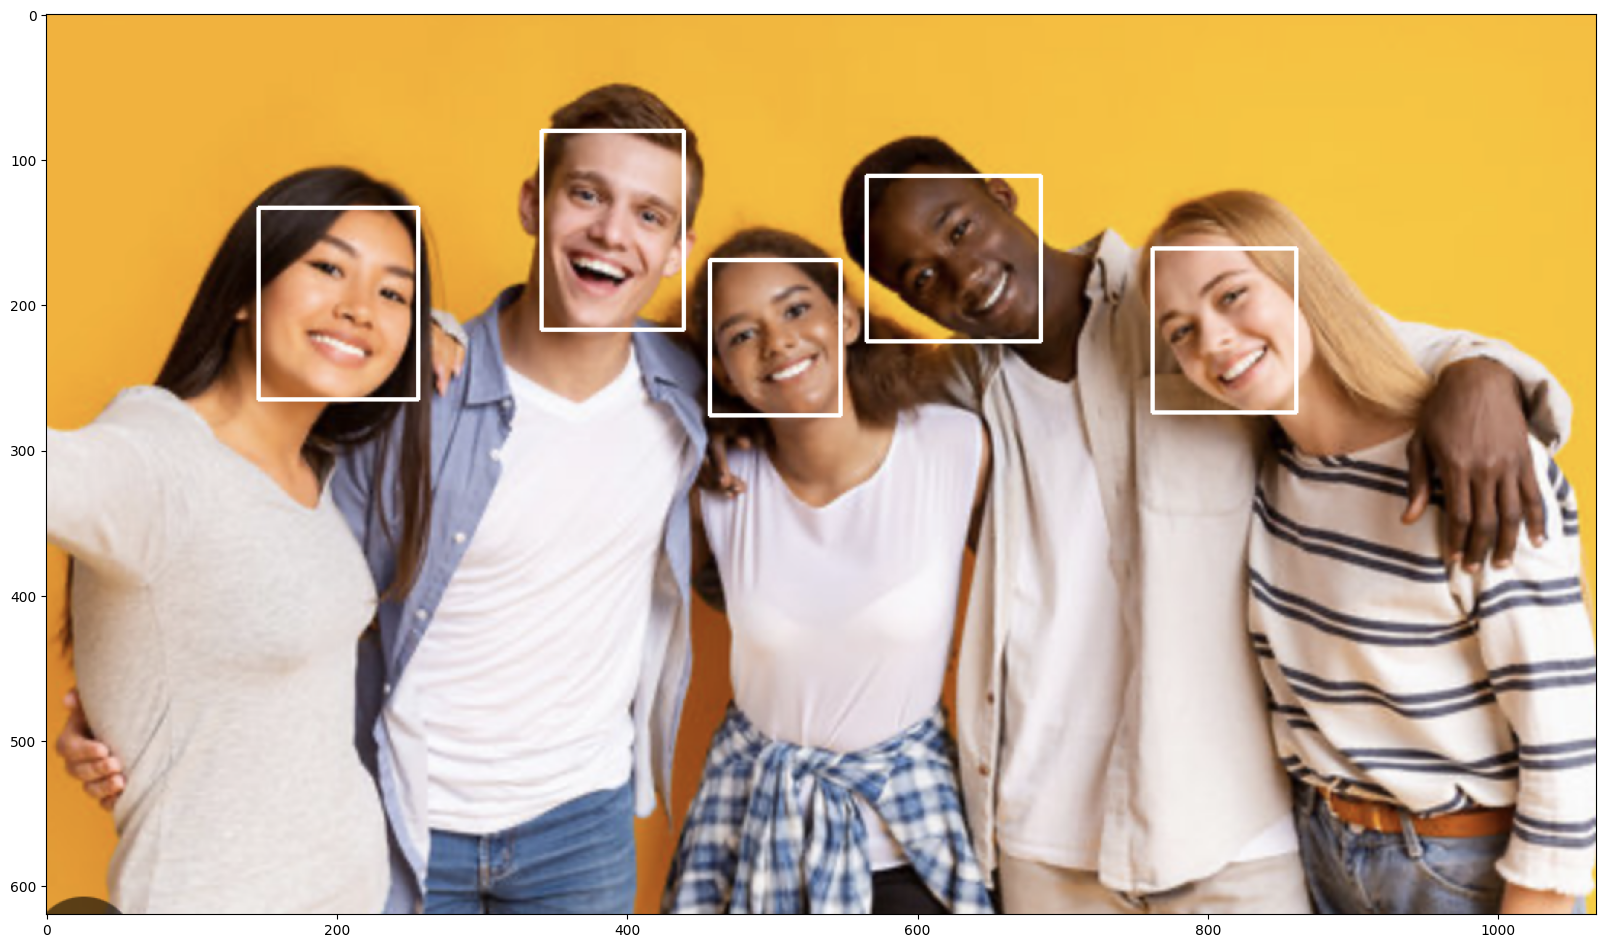

In [209]:
plt.figure(figsize = (20,20))
plt.imshow(img[:,:,::-1])
plt.show()

In [210]:
tilted_img = cv2.imread("tilted_img.png")
reps = RetinaFace.detect_faces(tilted_img)

In [211]:
x1, y1 = reps["face_1"]["landmarks"]["left_eye"]
x2, y2 = reps["face_1"]["landmarks"]["right_eye"]

In [212]:
a = abs(y1 - y2)
b = abs(x2 - x1)
c = math.sqrt(a*a + b*b)

print(a,b,c)

105.60724 95.147766 142.14776230431838


In [213]:
cos_alpha = (b*b + c*c - a*a) / (2*b*c)

In [214]:
cos_alpha 

np.float32(0.6693582)

In [215]:
alpha = np.arccos(cos_alpha) #radius

In [216]:
alpha = (alpha*180)/math.pi

In [217]:
alpha

np.float32(47.98245)

In [218]:
aligned_image = Image.fromarray(tilted_img)

In [219]:
aligned_img = np.array(aligned_image.rotate(-alpha))

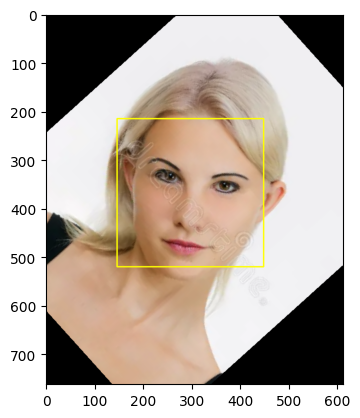

In [220]:
facialarea2 = reps["face_1"]["facial_area"]
cv2.rectangle(aligned_img, (facialarea2[0], facialarea2[1]), (facialarea2[2], facialarea2[3]), (0,255,255),2)
plt.imshow(aligned_img[:,:,::-1])
plt.show()